# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Business Understanding & Data Problem Definition

Goal: Help a used car dealership price inventory optimally and understand what attributes drive resale value so purchasing and merchandising decisions increase profitability.

Stakeholders: dealership management, buying team, sales, and marketing.

Key business questions:
- Which vehicle attributes (age, mileage, make/model, trim, condition, location, accident history, features) most influence price?
- Can we predict an accurate market price for each car to guide buy/sell decisions?
- Which inventory segments yield the highest margins?

Data problem (technical): Supervised regression task where the target is vehicle sale price. Input features include year, make, model, trim, mileage, engine/transmission specs, condition indicators, optional features, location, ownership/accident history, and derived features (age, mileage_per_year). Address class imbalance, missing values, outliers, and skewed price distribution (consider log-transform).

Approach & constraints:
- EDA to assess distributions, missingness, and collinearity.
- Feature engineering: age, mileage_per_year, categorical encoding, interaction terms, condition flags.
- Models: baseline linear models, tree-based models (RandomForest/GradientBoosting), and regularized regressions; use cross-validation and hyperparameter tuning.
- Interpretability: feature importances and partial dependence to generate actionable recommendations.
- Constraints: data quality, potential sampling bias, and privacy considerations.

Success criteria / metrics:
- Primary: cross-validated RMSE and MAE; business threshold such as X% of predictions within Y of actual.
- Secondary: R2 and model interpretability for actionable insights.


Deliverables:
- Cleaned dataset and EDA summary.
- Predictive models with evaluation.
- Feature importance and recommended pricing/stocking rules for the dealership.
- Short playbook for integrating model outputs into buying and listing workflows.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### The Data

Perform exploratory data analysis of the `vehicles.csv` to determine the features that will provide a prediction of target `price` of the vehicle. Load the data into a `pandas` data frame `df`.  For the `year` column drop the empty values using `dropna` method on the dataframe `df`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import textwrap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.filters.filtertools import convolution_filter
import statsmodels.graphics.tsaplots as tsplots
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.forecasting.stl import STLForecast


from warnings import filterwarnings 
filterwarnings('ignore')


In [3]:
df = pd.read_csv('./data/vehicles.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
df.dropna(subset="year",inplace=True)

For the data set `df` dataset three variables are used to capture the data for modeling features for prediction and time series analysis for predictions. `resale_window` will determine the period of used car data we are interested in analyzing. `used_car_sale` dataset will have the `all_feature` that we will further use in our model to fine tune the `price` prediction.

Use the `filter` to define the `price` range and `odometer` range to create the `used_car_sale` dataframe


In [6]:
resale_window = None
used_car_sale = None
all_feature = None
filter = None

In [7]:
resale_window = df[(df['year'] >= 2004) & (df['year'] <= 2018)].copy()
all_feature = ['manufacturer','model','fuel','year','price','odometer','state']
used_car_sale = resale_window[all_feature]
filter = ((used_car_sale['price'] >= 5000) & (used_car_sale['price'] <= 25000) & 
          (used_car_sale['odometer'] >= 10000) & (used_car_sale['odometer'] <= 160000))
used_car_sale = used_car_sale[filter].copy()


In [8]:
used_car_sale.info()

<class 'pandas.core.frame.DataFrame'>
Index: 157592 entries, 28 to 426871
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   manufacturer  153777 non-null  object 
 1   model         156735 non-null  object 
 2   fuel          156479 non-null  object 
 3   year          157592 non-null  float64
 4   price         157592 non-null  int64  
 5   odometer      157592 non-null  float64
 6   state         157592 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 9.6+ MB


In [9]:
used_car_sale.dropna(inplace=True)

### Feature Extraction

Based on the dataset `ordinal` features can be transformed using a `transformer` during the preprocessing step. Plot the top 5 categories of the selected features using `seaborn` library and ensure appropriate `labels` along with `feature` name is displayed for the plots. Use `subplots` appropriately and the save the image as `my_plot.png`


For the `numeric_features` in the `used_car_data` plot the `correlation_matrix` using `sns.heatmap`

In [10]:
numeric_features = ''
correlation_matrix = ''

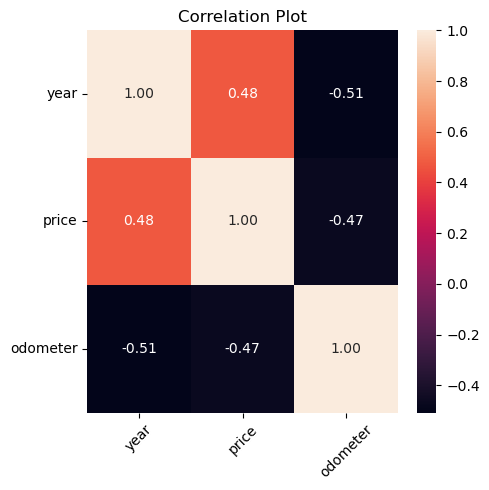

In [13]:
numeric_features = used_car_sale.select_dtypes(include=['number'])
correlation_matrix = numeric_features.corr()

fig = plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f')
plt.title('Correlation Plot')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
fig.savefig('./images/corr_matrix.png')

For the features in `used_car_sale` ensure all rows carry values using `isna` method on the `pandas.DataFrame`

In [14]:
print('Rows with missing price:', used_car_sale['price'].isna().sum())
print('Rows with missing year:', used_car_sale['year'].isna().sum())
print('Rows with missing manufacturer:', used_car_sale['manufacturer'].isna().sum())
print('Rows with missing model:', used_car_sale['model'].isna().sum())
print('Rows with missing fuel:', used_car_sale['fuel'].isna().sum())



Rows with missing price: 0
Rows with missing year: 0
Rows with missing manufacturer: 0
Rows with missing model: 0
Rows with missing fuel: 0


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

Create a `dataframe` that includes the columns which will be used as `feature` that will be modeled to `predict` the price based on the `usedcardataset`. 

In [15]:
print(used_car_sale.shape)
print(used_car_sale.isna().sum())


(151899, 7)
manufacturer    0
model           0
fuel            0
year            0
price           0
odometer        0
state           0
dtype: int64


### Sampling the data

Create a `X_train` and `X_test` pair of training and development dataset with `test_size = 0.3` and `random_state = 22`

In [23]:
X,y = '', ''
X_train, X_test, y_train, y_test = '','','',''

X = used_car_sale.drop('price', axis = 1)
y = used_car_sale['price'].astype(float) / 5000

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3,random_state=22)

print(X_train.shape)
print(X_test.shape)
print(type(X_train), type(y_train))


(106329, 6)
(45570, 6)
<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


### Baseline Metrics

Calculate the baseline `MSE` for test and train data by subtracting the mean of the `test` and `train` data from the dataset and use the `mean_squared_error` function store the values as `numpy.float`

In [24]:
baseline_train = ''
baseline_test = ''
mse_baseline_train = ''
mse_baseline_test = ''

baseline_train = pd.Series([y_train.mean()]*int(y_train.shape[0]))
baseline_test = pd.Series([y_test.mean()]*int(y_test.shape[0]))
mse_baseline_train = mean_squared_error(baseline_train, y_train)
mse_baseline_test = mean_squared_error(baseline_test, y_test)

print(baseline_train.shape, baseline_test.shape)
print(f'Baseline for training data: {mse_baseline_train:,.2f}')
print(f'Baseline for testing data: {mse_baseline_test:,.2f}')

(106329,) (45570,)
Baseline for training data: 1.28
Baseline for testing data: 1.28


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Preprocessing Pipeline

Using the identified feature create an instance of `ColumnTransformer` that implements a `Scaler Transformer` for `numeric features`, an `OrdinalEncoder` for the `ordinal_features`.

In [20]:
numeric_features = ['year', 'odometer']
ordinal_features = ['state']

X_transform = used_car_sale[numeric_features + ordinal_features].copy()
X_transform['odometer'] = X_transform['odometer'].astype(float) / 1e5

y_transform = used_car_sale['price']
y_transform = used_car_sale['price'].astype(float) / 5000


ordinal_categories = [
    sorted(used_car_sale['state'].dropna().unique().tolist())
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('ord', Pipeline(steps=[
            ('ordinal', OrdinalEncoder(categories=ordinal_categories))
        ]), ordinal_features)
    ]
)
print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


In [21]:
preprocessor

,transformers,"[('num', ...), ('ord', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Linear Regression Model

Create an instance of `Pipeline` with `named_steps` which includes the `preprocessor` and a `Polynomial Feature` transformation of degree `2` set the parameter `include_bias=False`. Implement the final named step that uses `LinearRegression()` as the regressor to fit the `training` data. Predict the output using `development` data set and calculate the `mean_squared_error`.

In [22]:
X_t_train, X_t_test, y_t_train, y_t_test = '','','',''
degrees = ''
results = []

X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(X_transform,y_transform,test_size = 0.3,random_state=22)

degrees = [1,2,3,4,5,6,7]
for degree in degrees:
    model = Pipeline(steps=[
            ('preprocess', preprocessor),
            ('polylin', PolynomialFeatures(degree=degree, include_bias=False)),
            ('linreg', LinearRegression())
        ])
    model.fit(X_t_train, y_t_train)
    pred = model.predict(X_t_test)
    mse = mean_squared_error(y_t_test, pred)
    results.append(mse)
    print("Degree", degree, "MSE", f'{mse:,.4f}')

mse_distribution = pd.DataFrame({"degree": degrees, "mse": results})

Degree 1 MSE 0.8947
Degree 2 MSE 0.8863
Degree 3 MSE 0.8825
Degree 4 MSE 0.8810
Degree 5 MSE 0.8796
Degree 6 MSE 0.8798
Degree 7 MSE 0.9035


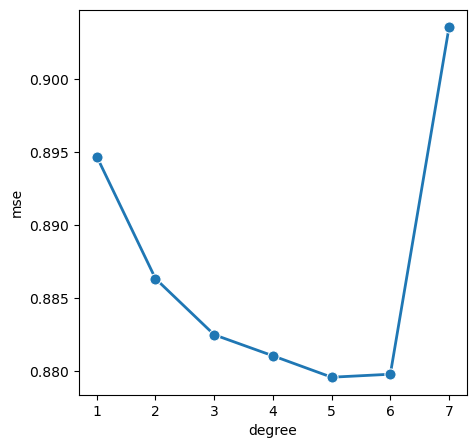

In [27]:
from scipy.interpolate import CubicSpline

plt.figure(figsize=(5, 5))
sns.lineplot(data=mse_distribution, x='degree', y='mse', marker='o', linewidth=2, markersize=8)


plt.show()
fig.savefig('./images/mse_distribution_linreg.png')

### Ridge Regression using GridSearch CV

Implement another instance of `Pipeline` to pipe_1 and included the named steps `preprocess`, `poly`, `scale` corresponding to the `preprocessor` pipline defined earlier, `PolynomialFeatures` with parameter `degree=1` and `include_bias=False`. Use the `ridge` regression method to model the data.

Assign the `ridge__alpha` choices to a `param_dict` for implementing `GridSearch CV`

In [28]:
pipe_ridge_model_1 = Pipeline([('preprocess', preprocessor),
                   ('polyridge', PolynomialFeatures(degree=5, include_bias=False)),
                   ('ridge', Ridge())])
param_dict = {'ridge__alpha': [0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]}

### Determine the penalty term

Using `GridSearchCV` for the `pipe_1`, set the `param_grid` to the dictionary containining  `ridge__alpha`. Determine the best model using the `best_estimator_` in the `grid_2` model after training the data using the `fit` method.

In [29]:

grid_2 = ''
model_2_train_mse = ''
model_2_test_mse = ''
model_2_best_alpha = ''

grid_2 = GridSearchCV(pipe_ridge_model_1, param_grid=param_dict)
grid_2.fit(X_t_train, y_t_train)
best_model = grid_2.best_estimator_
train_preds = best_model.predict(X_t_train)
test_preds = best_model.predict(X_t_test)
model_2_train_mse = mean_squared_error(y_t_train, train_preds)
model_2_test_mse = mean_squared_error(y_t_test, test_preds)
model_2_best_alpha = grid_2.best_params_
model_2_coef = best_model.named_steps["ridge"].coef_
# Answer check
print(f'Test MSE: {model_2_test_mse:,.4f}')
print(f'Best Ridge Alpha: {list(model_2_best_alpha.values())[0]}')
print(f'Best Ridge Coefficient: {model_2_coef}')


Test MSE: 0.8796
Best Ridge Alpha: 10.0
Best Ridge Coefficient: [ 2.38847581e-01 -4.31511028e-01 -1.15563855e-01 -3.48949534e-02
  4.22028985e-02  2.98477569e-02  6.54507612e-02  4.52880926e-03
  1.32461189e-02  1.47746562e-03  1.12064080e-01 -1.74685689e-03
  3.93979648e-02  6.88938170e-03 -1.49527840e-03  2.71769453e-03
  4.86313260e-03 -1.34133618e-04 -6.38149461e-04  1.27086999e-02
 -2.85612725e-02 -5.68511700e-04  3.94868984e-02 -1.13580552e-03
  1.34545602e-04  4.73897468e-02 -5.43158855e-03 -3.03475626e-04
  3.52464033e-05  7.95231133e-03 -3.02365646e-03 -1.63157418e-04
  2.51469904e-06  1.33394024e-05 -1.87524747e-03 -2.45969197e-02
  4.11929550e-05  1.00987827e-02 -9.23752475e-05  1.30298464e-05
  1.31572571e-02 -5.60178984e-04  1.90540395e-05 -1.65801583e-06
  1.37301372e-02 -6.54499047e-04  8.33804731e-05  4.23465177e-06
 -3.19322952e-07  1.19919870e-02 -2.47784015e-04  5.53815125e-05
  1.75388719e-06 -3.13570231e-08 -9.99657386e-08]


In [30]:
best_model

,steps,"[('preprocess', ...), ('polyridge', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Feature Coefficient of the best model

List the feature_names using `get_feature_names_out` method of the name_step `poly` of the `best_model` and assign to `ridge_df` DataFrame

In [31]:
feature_names = best_model.named_steps['polyridge'].get_feature_names_out(X_transform.columns)
ridge_df = pd.DataFrame({'feature': feature_names, 'coef': model_2_coef})
# Answer check
print(type(ridge_df))
ridge_df.loc[ridge_df['coef'] != 0].head(5)

<class 'pandas.core.frame.DataFrame'>


,feature,coef
0,year,0.238848
1,odometer,-0.431511
2,state,-0.115564
3,year^2,-0.034895
4,year odometer,0.042203


### Grid Search CV using k-Fold Cross-Validation

Using the `GridSearchCV` method create model that uses the entire sample dataset instead of `training` and `development` dataset to perform `cross_validation` and determine the best `Ridge Alpha` for the `hyperparameter`.


In [32]:

grid_3 = ''
model_3_train_mse = ''
model_3_test_mse = ''
model_3_best_alpha = ''

grid_3 = GridSearchCV(pipe_ridge_model_1, param_grid=param_dict, cv = 10)
grid_3.fit(X_transform, y_transform)
best_model = grid_3.best_estimator_
test_train_preds = best_model.predict(X_transform)
model_3_train_mse = mean_squared_error(y_transform, test_train_preds)
model_3_best_alpha = grid_2.best_params_
model_3_coef = best_model.named_steps["ridge"].coef_
print(f'Test MSE: {model_3_train_mse:,.4f}')
print(f'Best Ridge Alpha: {list(model_3_best_alpha.values())[0]}')


Test MSE: 0.8842
Best Ridge Alpha: 10.0


### Lasso Model for Sparse Feature Selection

In [34]:
lasso_results = []
for alpha in [0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]:
    model_lasso = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('polylasso', PolynomialFeatures(degree=2, include_bias=False)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model_lasso.fit(X_t_train, y_t_train)
    pred = model_lasso.predict(X_t_test)
    mse = mean_squared_error(y_t_test, pred)
    lasso_results.append((mse, alpha))
    print(f'alpha={alpha} -> MSE={mse:,.2f}')

best_lasso_mse, best_lasso_alpha = min(lasso_results, key=lambda x: x[0])
print(f'\nBest Lasso alpha: {best_lasso_alpha}')
print(f'Best test MSE: {best_lasso_mse:,.2f}')


alpha=0.001 -> MSE=0.89
alpha=0.1 -> MSE=0.94
alpha=1.0 -> MSE=1.01
alpha=10.0 -> MSE=1.18
alpha=100.0 -> MSE=1.28
alpha=1000.0 -> MSE=1.28

Best Lasso alpha: 0.001
Best test MSE: 0.89


In [35]:
best_lasso_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('polylasso', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', Lasso(alpha=best_lasso_alpha))
])
best_lasso_model.fit(X_t_train, y_t_train)

# Show the non-zero coefficients to interpret which features were retained
coef = best_lasso_model.named_steps['lasso'].coef_
print('Number of non-zero coefficients:', sum(coef != 0))
print('Coefficient values (first 20):', coef[:20])


Number of non-zero coefficients: 9
Coefficient values (first 20): [ 3.73647524e-01 -3.14934410e-01 -9.85665508e-03  6.84911092e-02
  6.81314600e-02  1.28531765e-03  8.48325999e-02  1.84532763e-05
  1.96236694e-04]


In [36]:

feature_names = best_lasso_model.named_steps['polylasso'].get_feature_names_out(X_transform.columns)
lasso_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
# Answer check
print(type(feature_names))
lasso_df.loc[lasso_df['coef'] != 0]

<class 'numpy.ndarray'>


,feature,coef
0,year,0.373648
1,odometer,-0.314934
2,state,-0.009857
3,year^2,0.068491
4,year odometer,0.068131
5,year state,0.001285
6,odometer^2,0.084833
7,odometer state,0.000018
8,state^2,0.000196


### Time Series model using ARMA model

In [38]:
used_car_sale_ts = used_car_sale
used_car_sale_ts['year'] = pd.to_datetime(used_car_sale_ts['year'], format = '%Y')


In [39]:
used_car_sale_ts

,manufacturer,model,fuel,year,price,odometer,state
28,chevrolet,silverado 1500,gas,2010-01-01,22590,71229.0,al
31,ford,f-150 xlt,gas,2013-01-01,15000,128000.0,al
39,chevrolet,silverado 1500 regular,gas,2017-01-01,24590,40784.0,al
51,ram,1500 regular cab tradesman,gas,2017-01-01,22590,39508.0,al
55,ford,f250 super duty,diesel,2004-01-01,19900,88000.0,al
...,...,...,...,...,...,...,...
426850,bmw,x5,gas,2013-01-01,13777,104339.0,wy
426852,honda,civic,gas,2011-01-01,6977,112396.0,wy
426854,toyota,matrix,gas,2009-01-01,7977,142868.0,wy
426855,fiat,500,gas,2012-01-01,7477,64267.0,wy


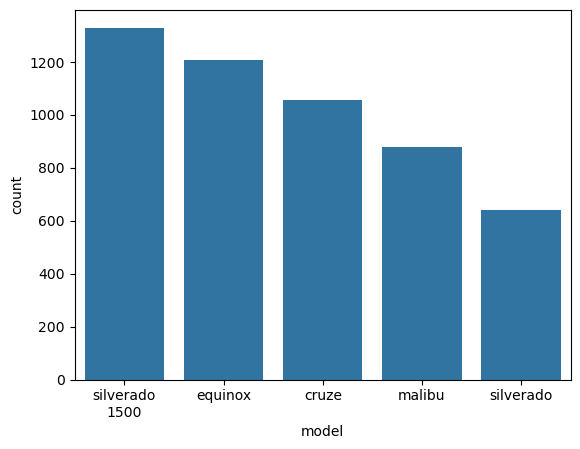

<Figure size 640x480 with 0 Axes>

In [41]:

ax = sns.barplot(data = used_car_sale_ts[used_car_sale_ts['manufacturer'] == 'chevrolet']['model'].dropna().value_counts().head(5))
labels = [textwrap.fill(label.get_text(), 12) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)
plt.show()

plt.savefig('./images/chevrolet_sample5.png', dpi=300, bbox_inches="tight")


In [42]:
used_car_sale_ts = used_car_sale_ts.set_index("year")

In [43]:
used_car_sale_ts_year = used_car_sale_ts[['price']].resample('YE').mean()

In [44]:
used_car_sale_ts_year

,price
year,
2004-12-31,10513.950707
2005-12-31,10413.150325
2006-12-31,9669.620355
2007-12-31,10028.121251
2008-12-31,10543.051555
2009-12-31,10337.132147
2010-12-31,11047.996442
2011-12-31,12067.025656
2012-12-31,12722.749453


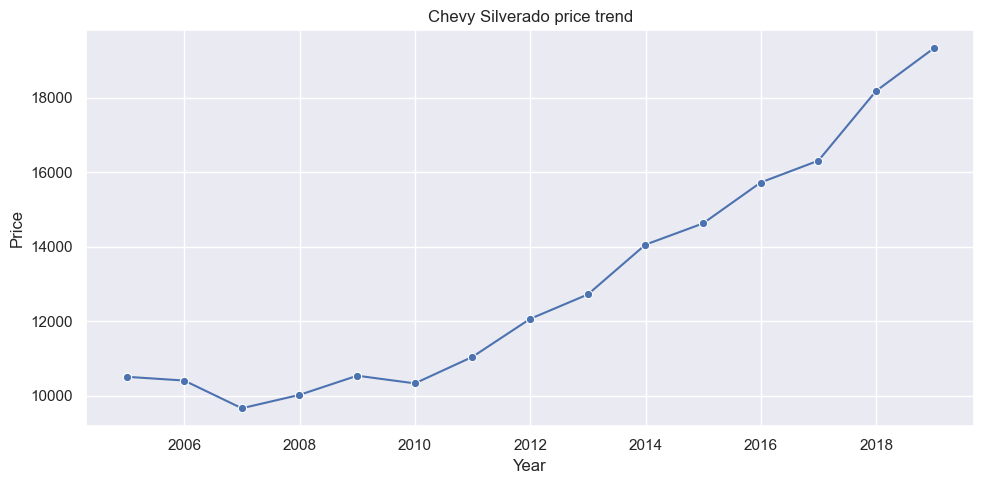

<Figure size 640x480 with 0 Axes>

In [45]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=used_car_sale_ts_year, x=used_car_sale_ts_year.index, y="price", marker="o")
ax.set_title("Chevy Silverado price trend")
ax.set_xlabel("Year")
ax.set_ylabel("Price")
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('./images/chevy_price_trend.png', dpi=300, bbox_inches="tight")


In [46]:

y_hist = ''
y_future = ''

y_hist = used_car_sale_ts_year[['price']].loc[:'2016-12-31']
y_future = used_car_sale_ts_year[['price']].loc['2017-01-01':]
print('Historical:')
print(y_hist.tail())
print('=========\nFuture:')
print(y_future.head())

Historical:
                   price
year                    
2012-12-31  12722.749453
2013-12-31  14058.830618
2014-12-31  14628.967013
2015-12-31  15726.611208
2016-12-31  16313.196629
Future:
                   price
year                    
2017-12-31  18181.046898
2018-12-31  19324.483004


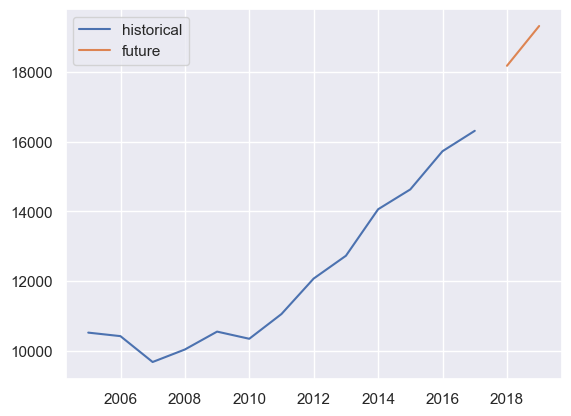

In [47]:
plt.plot(y_hist, label = 'historical')
plt.plot(y_future, label = 'future')
plt.legend()
plt.savefig('./images/chevy_price_future.png', dpi=300, bbox_inches="tight")


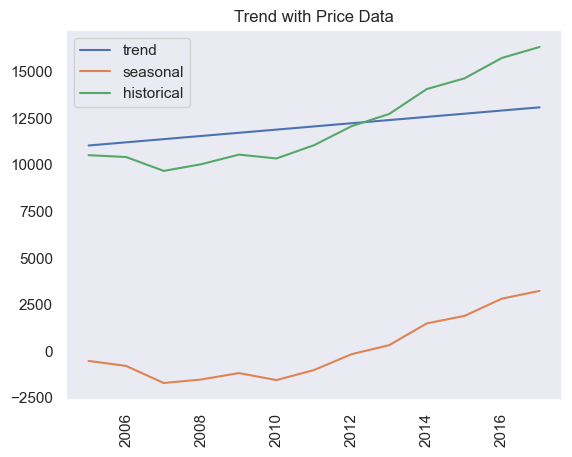

In [48]:
stl = ''
results = ''

stl = STL(y_hist, period=12)
results = stl.fit()
plt.plot(results.trend, label = 'trend')
plt.plot(results.seasonal, label = 'seasonal')
plt.plot(y_hist, label = 'historical')
plt.title('Trend with Price Data')
plt.grid()
plt.legend()
plt.xticks(rotation = 90);
plt.savefig('./images/my_plot_stl_trend_season_price.png', dpi=300, bbox_inches="tight")


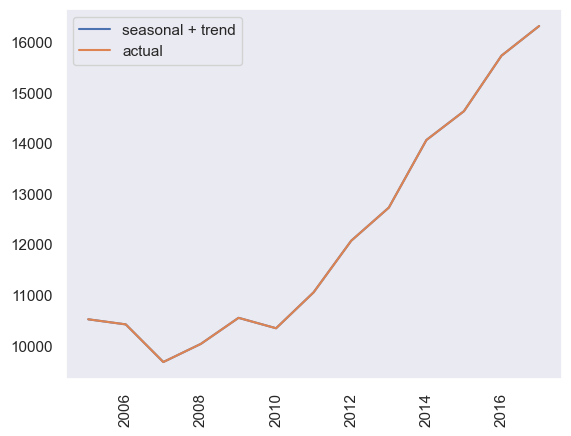

In [49]:
season_and_trend = ''

season_and_trend = results.trend + results.seasonal

plt.plot(season_and_trend, label = 'seasonal + trend')
plt.plot(y_hist, label = 'actual')
plt.grid()
plt.legend()
plt.xticks(rotation = 90);
plt.savefig('./images/my_plot_stl_trend+season_price.png', dpi=300, bbox_inches="tight")


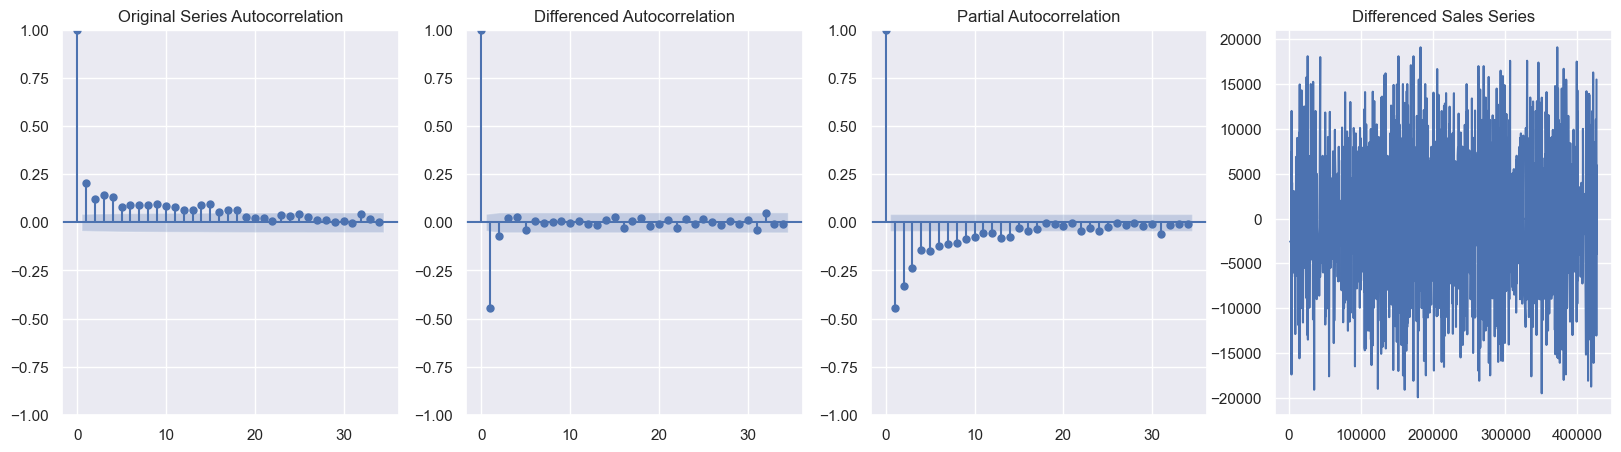

In [50]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
plot_acf(used_car_sale[(used_car_sale['manufacturer'] == 'ford') & (used_car_sale['model'] == 'f-150')]['price'], ax = ax[0]);
ax[0].set_title('Original Series Autocorrelation')
plot_acf(used_car_sale[(used_car_sale['manufacturer'] == 'ford') & (used_car_sale['model'] == 'f-150')]['price'].diff().dropna(), ax = ax[1]);
ax[1].set_title('Differenced Autocorrelation')
plot_pacf(used_car_sale[(used_car_sale['manufacturer'] == 'ford') & (used_car_sale['model'] == 'f-150')]['price'].diff().dropna(), ax = ax[2], method = 'ywm');
ax[3].set_title('Partial Autocorrelation Function');
ax[3].plot(used_car_sale[(used_car_sale['manufacturer'] == 'ford') & (used_car_sale['model'] == 'f-150')]['price'].diff().dropna())
ax[3].set_title('Differenced Sales Series');
fig.savefig('./images/acf.png', dpi=300, bbox_inches="tight")


In [51]:
y_future.index = pd.to_datetime(y_future.index, format = '%Y')

In [52]:
y_future

,price
year,
2017-12-31,18181.046898
2018-12-31,19324.483004


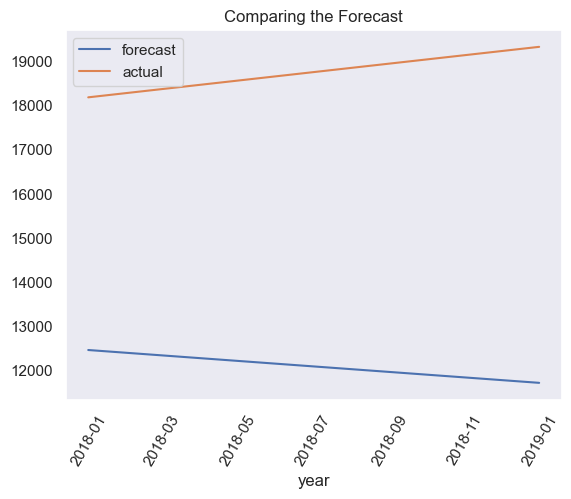

In [54]:
stlf = STLForecast(y_hist, ARIMA, model_kwargs={'order':(1, 1, 0), 'trend':"t"}, period=12).fit()

forecast = stlf.forecast(len(y_future))
forecast_series = pd.Series(forecast.values, index=y_future.index)
actual_series = y_future['price']

sns.lineplot(x=forecast_series.index, y=forecast_series.values, label='forecast')
sns.lineplot(x=actual_series.index, y=actual_series.values, label='actual')
plt.title('Comparing the Forecast')
plt.legend()
plt.xticks(rotation=60)
plt.grid()
fig.savefig('./images/forecast.png', dpi=300, bbox_inches="tight")


In [55]:
y_future.index = pd.to_datetime(y_future.index, format = '%Y')

In [56]:
y_future

,price
year,
2017-12-31,18181.046898
2018-12-31,19324.483004


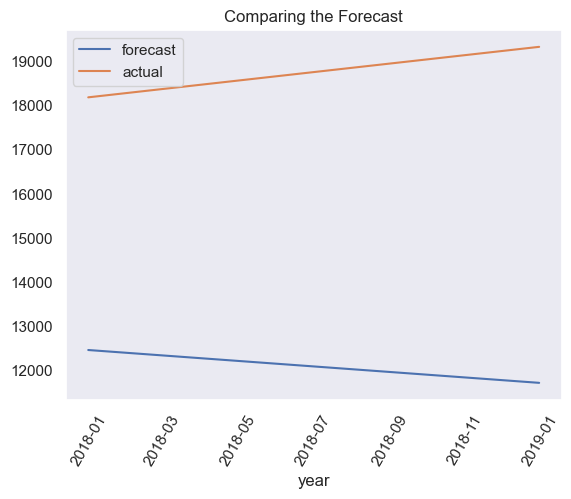

In [58]:
stlf = STLForecast(y_hist, ARIMA, model_kwargs={'order':(1, 1, 0), 'trend':"t"}, period=12).fit()

forecast = stlf.forecast(len(y_future))
forecast_series = pd.Series(forecast.values, index=y_future.index)
actual_series = y_future['price']

sns.lineplot(x=forecast_series.index, y=forecast_series.values, label='forecast')
sns.lineplot(x=actual_series.index, y=actual_series.values, label='actual')
plt.title('Comparing the Forecast')
plt.legend()
plt.xticks(rotation=60)
plt.grid()
plt.savefig('./images/comparingforecast.png')

In [59]:
used_car_sale_ts_year

,price
year,
2004-12-31,10513.950707
2005-12-31,10413.150325
2006-12-31,9669.620355
2007-12-31,10028.121251
2008-12-31,10543.051555
2009-12-31,10337.132147
2010-12-31,11047.996442
2011-12-31,12067.025656
2012-12-31,12722.749453


In [60]:
X_ts = used_car_sale[(used_car_sale['manufacturer'] == 'ford') & (used_car_sale['model'] == 'f-150')]
X_ts = X_ts[["year","price"]]
X_ts.set_index("year",inplace=True)
X_ts = X_ts[['price']].resample('YE').mean()


In [61]:
pval = ''

pval = adfuller(X_ts)[1]

# Answer check
print(f'The p-value is {pval: .4f}')

The p-value is  0.7846


In [62]:


sarima_ts = SARIMAX(X_ts, order = (1, 0, 1), seasonal_order = (1, 0, 1, 12)).fit(disp=0)

### ANSWER CHECK
sarima_ts.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              price   No. Observations:                   15
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -135.070
Date:                            Tue, 21 Jul 2026   AIC                            280.141
Time:                                    05:11:05   BIC                            283.681
Sample:                                12-31-2004   HQIC                           280.103
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9887      0.030     32.581      0.000       0.929       1.048
ma.L1          0.0792      0.418      0.189      0.850      -0.740       0.898
ar.S.L12       0.1736      2.303      0.075      0.940      -4.341       4.688
ma.S.L12       0.7543      2.859      0.264      0.792      -4.849       6.357
sigma2      1.554e+06   2.78e-06   5.59e+11      0.000    1.55e+06    1.55e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.94   Jarque-Bera (JB):                 0.59
Prob(Q):                              0.33   Prob(JB):                         0.74
Heteroskedasticity (H):               0.95   Skew:                            -0.31
Prob(H) (two-sided):                  0.96   Kurtosis:                         2.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.39e+28. Standard errors may be unstable.
"""

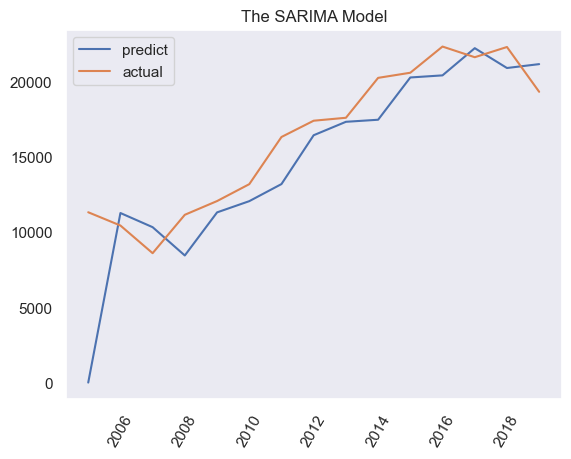

In [64]:
plt.plot(X_ts.index, sarima_ts.predict(), label = 'predict')
plt.plot(X_ts.index, X_ts, label = 'actual')
plt.xticks(rotation = 60)
plt.title('The SARIMA Model')
plt.grid();
plt.legend()
plt.savefig('./images/sarima.png', dpi=300, bbox_inches="tight")


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.